In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Geometry and Linear Algebraic Operations

In that section, we encountered the basics of linear algebra
and saw how it could be used to express common operations for transforming our data.
Linear algebra is one of the pillars
underlying much of the work that we do in deep learning
and in machine learning more broadly.
While that section contained enough machinery
to communicate the mechanics of modern deep learning models,
there is a lot more to the subject.
In this section, we will go deeper,
building geometric intuition for vectors, angles, projections,
hyperplanes, and the way matrices reshape space.
These pictures are the foundation for the two matrix decompositions
that run through all of deep learning, which we develop in the
sections that follow: *eigendecomposition*
(that section), the tool for analyzing
stability, PCA, and Hessians; and the *singular value decomposition*
(that section), the tool behind low-rank
approximation, conditioning, and LoRA.

## Vectors and Their Geometry

### Points and Directions

A vector admits two common geometric readings, as a point or as a direction
in space. We use the following imports throughout the section.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch
import torchvision
from torchvision import transforms

Read as a *point*, a vector's components give its location relative to a
fixed reference called the *origin*: $\mathbf{v} = [3,2]^\top$ is the point
$3$ units to the right of the origin and $2$ units up. This reading turns a
dataset into a cloud of points, and a task such as telling pictures of cats
from pictures of dogs into geometry: find a way to separate two clusters of
points in space.

Read as a *direction*, the same vector says "take $3$ steps to the right and
$2$ steps up." An arrow with that displacement can start anywhere, so all the
parallel arrows in the figure are the same vector. (On
notation: a single vector is by default a *column*, while in a matrix holding
a tabular dataset each data example is conventionally a *row*, as described in
that section.)

![A vector can be read two ways: as a *point* whose first component is the $x$-coordinate and second is the $y$-coordinate (left), or as a *direction*, an arrow that can start anywhere, so every arrow shown is the same vector $(3,2)^\top$ (right).](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-vectors.svg)

The direction view makes vector addition visual: follow one arrow, then the
other, tip to tail, as in the figure.

![We can visualize vector addition by first following one vector, and then another, placing them tip to tail.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-vector-add.svg)

Vector subtraction has a similar interpretation: from the identity
$\mathbf{u} = \mathbf{v} + (\mathbf{u}-\mathbf{v})$, the vector
$\mathbf{u}-\mathbf{v}$ is the direction that takes us from the point
$\mathbf{v}$ to the point $\mathbf{u}$.


### Dot Products and Angles
As we saw in that section,
if we take two column vectors $\mathbf{u}$ and $\mathbf{v}$,
we can form their dot product by computing:

$$\mathbf{u}^\top\mathbf{v} = \sum_i u_i\cdot v_i.$$

Because the equation is symmetric, we will mirror the notation
of classical multiplication and write

$$
\mathbf{u}\cdot\mathbf{v} = \mathbf{u}^\top\mathbf{v} = \mathbf{v}^\top\mathbf{u},
$$

to highlight the fact that exchanging the order of the vectors will yield the same answer.

The dot product the equation also admits a geometric interpretation: it is closely related to the angle between two vectors.  Consider the angle shown in the figure.

![Between any two vectors in the plane there is a well defined angle $\theta$.  We will see this angle is intimately tied to the dot product.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-angle.svg)

To start, let's consider two specific vectors:

$$
\mathbf{v} = (r,0) \; \textrm{and} \; \mathbf{w} = (s\cos(\theta), s \sin(\theta)).
$$

The vector $\mathbf{v}$ is length $r$ and runs parallel to the $x$-axis,
and the vector $\mathbf{w}$ is of length $s$ and at angle $\theta$ with the $x$-axis.
If we compute the dot product of these two vectors, we see that

$$
\mathbf{v}\cdot\mathbf{w} = rs\cos(\theta) = \|\mathbf{v}\|\|\mathbf{w}\|\cos(\theta).
$$

In short, for these two specific vectors the dot product, combined with the
norms, tells us the angle between them. The same identity holds for **any**
pair of vectors, in any number of dimensions. Two short arguments *justify*
the formula and pin down exactly when it makes sense.

The first argument is purely planar. Any two vectors $\mathbf{v}$ and
$\mathbf{w}$, however many coordinates they have, both lie in the
two-dimensional plane they span, and the angle $\theta$ between them lives in
that plane. So we lose nothing by reasoning in two dimensions. Expanding
$\|\mathbf{v} - \mathbf{w}\|^2$ with the dot product gives

$$
\|\mathbf{v} - \mathbf{w}\|^2
 = (\mathbf{v}-\mathbf{w})\cdot(\mathbf{v}-\mathbf{w})
 = \|\mathbf{v}\|^2 - 2\,\mathbf{v}\cdot\mathbf{w} + \|\mathbf{w}\|^2,
$$

while the planar law of cosines applied to the triangle with sides
$\mathbf{v}$, $\mathbf{w}$, and $\mathbf{v}-\mathbf{w}$ gives

$$
\|\mathbf{v} - \mathbf{w}\|^2
 = \|\mathbf{v}\|^2 + \|\mathbf{w}\|^2 - 2\,\|\mathbf{v}\|\|\mathbf{w}\|\cos\theta.
$$

Equating the two and cancelling $\|\mathbf{v}\|^2 + \|\mathbf{w}\|^2$ leaves the
**geometric formula for the dot product**,

$$
\mathbf{v}\cdot\mathbf{w} = \|\mathbf{v}\|\|\mathbf{w}\|\cos\theta,
$$

which we may solve for the angle:

$$\theta = \arccos\left(\frac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{v}\|\|\mathbf{w}\|}\right).$$

Nothing in the computation referenced the ambient dimension, so
the equation holds in three or three million dimensions
without change.

There is, however, a subtlety we must not skip. The function $\arccos$ is only
defined on the interval $[-1, 1]$, so the equation is
meaningful *only if* the fraction inside it never escapes that interval. That
this is guaranteed, in every dimension, is the content of the following
inequality.

**Proposition (Cauchy–Schwarz).** *For any vectors $\mathbf{v}, \mathbf{w}$,*

$$
|\mathbf{v}\cdot\mathbf{w}| \le \|\mathbf{v}\|\,\|\mathbf{w}\|,
$$

*with equality if and only if $\mathbf{v}$ and $\mathbf{w}$ are collinear
(one is a scalar multiple of the other).*

**Proof.** If $\mathbf{w} = \mathbf{0}$ both sides are zero and there is
nothing to prove, so assume $\mathbf{w} \neq \mathbf{0}$. The trick is to look
at the squared length of $\mathbf{v} - t\mathbf{w}$ as a function of the real
number $t$. A squared length is never negative, so

$$
q(t) = \|\mathbf{v} - t\mathbf{w}\|^2
     = \|\mathbf{w}\|^2\, t^2 - 2(\mathbf{v}\cdot\mathbf{w})\, t + \|\mathbf{v}\|^2
     \;\ge\; 0
     \quad\textrm{for every } t.
$$

This is a quadratic in $t$ with positive leading coefficient $\|\mathbf{w}\|^2$.
A quadratic that stays non-negative cannot have two distinct real roots, so its
discriminant must be $\le 0$:

$$
\bigl(2\,\mathbf{v}\cdot\mathbf{w}\bigr)^2 - 4\,\|\mathbf{w}\|^2\,\|\mathbf{v}\|^2 \le 0,
\qquad\textrm{i.e.}\qquad
(\mathbf{v}\cdot\mathbf{w})^2 \le \|\mathbf{v}\|^2\,\|\mathbf{w}\|^2.
$$

Taking square roots gives the equation. Equality forces the
discriminant to vanish, which means $q$ has a (repeated) real root $t^\star$
with $q(t^\star) = \|\mathbf{v} - t^\star\mathbf{w}\|^2 = 0$, that is
$\mathbf{v} = t^\star \mathbf{w}$. $\blacksquare$

The whole argument used nothing but the fact that *a squared length is
non-negative*. Dividing the equation by
$\|\mathbf{v}\|\|\mathbf{w}\|$ for nonzero $\mathbf{v}, \mathbf{w}$ yields the
**well-definedness of the angle**:

$$
-1 \;\le\; \frac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{v}\|\,\|\mathbf{w}\|} \;\le\; 1,
$$

so the $\arccos$ in the equation is always defined and
$\theta$ is a genuine angle in $[0, \pi]$, no matter the dimension. The
equality cases are exactly the familiar ones: $\cos\theta = +1$ ($\theta = 0$)
when the vectors point the same way, and $\cos\theta = -1$ ($\theta = \pi$)
when they point in opposite directions, precisely the collinear cases of the
proposition.

Cauchy–Schwarz also has a one-picture summary, shown in
the figure. It is a way to *remember* the inequality
rather than a second proof, since the picture reads off the angle $\theta$
(and with it the equation) that Cauchy–Schwarz itself makes
legitimate.
On the left, the projection of $\mathbf{v}$
onto $\mathbf{w}$ has signed length $\|\mathbf{v}\|\cos\theta$, and the residual
$\mathbf{r} = \mathbf{v} - \operatorname{proj}_{\mathbf{w}}\mathbf{v}$ meets
$\mathbf{w}$ at a right angle (we prove both facts in the next section). Because
the right triangle's hypotenuse $\mathbf{v}$ can be no shorter than its leg,
$\|\mathbf{v}\|\,|\cos\theta| \le \|\mathbf{v}\|$, which is exactly
$|\mathbf{v}\cdot\mathbf{w}| \le \|\mathbf{v}\|\|\mathbf{w}\|$. On the right is
the equality case: when $\mathbf{v}$ is collinear with $\mathbf{w}$ the residual
vanishes and the inequality becomes an equality.

![Left: the orthogonal projection of $\mathbf{v}$ onto $\mathbf{w}$ has signed length $\|\mathbf{v}\|\cos\theta$, and the residual $\mathbf{r}$ meets $\mathbf{w}$ at a right angle, so $\mathbf{v}$ is the hypotenuse of a right triangle. Right: the Cauchy–Schwarz equality case, where $\mathbf{v}$ is collinear with $\mathbf{w}$ and the residual vanishes.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-projection.svg)

Cauchy–Schwarz immediately gives the **triangle inequality**, which says
that a detour through a third point is never shorter than going straight.

**Corollary (triangle inequality).** *For any $\mathbf{v}, \mathbf{w}$,*
$\|\mathbf{v} + \mathbf{w}\| \le \|\mathbf{v}\| + \|\mathbf{w}\|$.

**Proof.** Expand and apply the equation:

$$
\|\mathbf{v} + \mathbf{w}\|^2
 = \|\mathbf{v}\|^2 + 2\,\mathbf{v}\cdot\mathbf{w} + \|\mathbf{w}\|^2
 \le \|\mathbf{v}\|^2 + 2\,\|\mathbf{v}\|\|\mathbf{w}\| + \|\mathbf{w}\|^2
 = \bigl(\|\mathbf{v}\| + \|\mathbf{w}\|\bigr)^2.
$$

Taking square roots gives the claim. $\blacksquare$

As a simple example, let's see how to compute the angle between a pair of vectors:

In [2]:
import numpy as onp
def angle(v, w):
    return onp.arccos(v.dot(w) / (onp.linalg.norm(v) * onp.linalg.norm(w)))

angle(onp.array([0, 1, 2]), onp.array([2, 3, 4]))

np.float64(0.4189900840328574)

Two vectors whose angle is $\pi/2$ (equivalently $90^{\circ}$) are called
*orthogonal*. From the equation, the angle is $\pi/2$ exactly when
$\cos\theta = 0$, and since $\|\mathbf{v}\|\|\mathbf{w}\| \neq 0$ for nonzero
vectors, this happens if and only if the dot product itself vanishes. We
therefore *define* two vectors to be **orthogonal when**
$\mathbf{v}\cdot\mathbf{w} = 0$. (We take this as the definition because it
extends gracefully to the zero vector, which is orthogonal to everything even
though no angle is defined for it.) We will use this condition throughout the
chapter.

### Projection and Orthogonality

Cauchy–Schwarz answers "how aligned are two vectors?"; the closely related
operation of *projection* answers "how much of $\mathbf{v}$ points along
$\mathbf{w}$?" Geometrically, we look for the point on the line
$\{t\mathbf{w} : t \in \mathbb{R}\}$ that is closest to $\mathbf{v}$.

**Proposition (orthogonal projection).** *Let $\mathbf{w} \neq \mathbf{0}$. The
closest multiple of $\mathbf{w}$ to $\mathbf{v}$ is*

$$
\operatorname{proj}_{\mathbf{w}}\mathbf{v}
 = \frac{\mathbf{v}\cdot\mathbf{w}}{\mathbf{w}\cdot\mathbf{w}}\,\mathbf{w},
$$

*and the residual $\mathbf{r} = \mathbf{v} - \operatorname{proj}_{\mathbf{w}}\mathbf{v}$
is orthogonal to $\mathbf{w}$.*

**Proof.** We minimize the squared distance
$f(t) = \|\mathbf{v} - t\mathbf{w}\|^2
 = \|\mathbf{w}\|^2 t^2 - 2(\mathbf{v}\cdot\mathbf{w})\,t + \|\mathbf{v}\|^2$.
This is a convex parabola in $t$; setting $f'(t) = 2\|\mathbf{w}\|^2 t -
2(\mathbf{v}\cdot\mathbf{w}) = 0$ gives the unique minimizer
$t^\star = \dfrac{\mathbf{v}\cdot\mathbf{w}}{\mathbf{w}\cdot\mathbf{w}}$, which
is the equation. For orthogonality of the residual, compute

$$
\mathbf{r}\cdot\mathbf{w}
 = \mathbf{v}\cdot\mathbf{w}
   - \frac{\mathbf{v}\cdot\mathbf{w}}{\mathbf{w}\cdot\mathbf{w}}\,(\mathbf{w}\cdot\mathbf{w})
 = 0. \qquad \blacksquare
$$

Because $\mathbf{r}$ is orthogonal to $\operatorname{proj}_{\mathbf{w}}\mathbf{v}$
(which is a multiple of $\mathbf{w}$), the decomposition
$\mathbf{v} = \operatorname{proj}_{\mathbf{w}}\mathbf{v} + \mathbf{r}$ splits
$\mathbf{v}$ into two perpendicular pieces, and **Pythagoras** applies:

$$
\|\mathbf{v}\|^2 = \|\operatorname{proj}_{\mathbf{w}}\mathbf{v}\|^2 + \|\mathbf{r}\|^2 .
$$

Two remarks tie this back to the rest of the section. First, the *signed
length* of the projection is

$$
\frac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{w}\|} = \|\mathbf{v}\|\cos\theta ,
$$

which is exactly the quantity the hyperplane discussion below will use, so the
hyperplane material is now fully self-contained. Second, we just solved a
*least-squares* problem in one dimension: we found the best approximation of
$\mathbf{v}$ from the subspace spanned by $\mathbf{w}$. We state the general
version below, as soon as the vocabulary of subspaces and bases is in hand.

### Span, Bases, and Subspaces

The projection result spoke of "the one-dimensional subspace spanned by
$\mathbf{w}$," and the planar argument for the dot-product formula reasoned
inside the plane that two vectors span. These words (*span*, *subspace*,
*basis*) are the organizing vocabulary of linear algebra, and the
decompositions later in this chapter lean on them constantly, so let us pin
them down. 

Given vectors $\mathbf{v}_1, \ldots, \mathbf{v}_k$, their **span** is the set
of everything reachable by scaling and adding them:

$$
\operatorname{span}(\mathbf{v}_1, \ldots, \mathbf{v}_k)
 = \bigl\{ a_1\mathbf{v}_1 + \cdots + a_k\mathbf{v}_k
   : a_1, \ldots, a_k \in \mathbb{R} \bigr\}.
$$

A weighted sum $a_1\mathbf{v}_1 + \cdots + a_k\mathbf{v}_k$ is called a
*linear combination*, so the span is the set of all linear combinations. In
$\mathbb{R}^2$ the possibilities are easy to picture
(the figure): the span of a single nonzero vector is the line
through the origin in its direction, while the span of two vectors that do not
lie on a common line is the entire plane. A span is closed under further
addition and scaling, and any set of vectors with that closure property is
called a **subspace**. The complete list of subspaces of $\mathbb{R}^2$ is
short: the origin alone, the lines through the origin, and $\mathbb{R}^2$
itself; in $\mathbb{R}^3$, the planes through the origin join the list. Note
that every subspace contains the origin (scale any of its elements by zero),
so a line that misses the origin is not a subspace.

![Left: the span of a single nonzero vector $\mathbf{v}$, the set of all of its scalar multiples, is the line through the origin in its direction, a one-dimensional subspace. Right: two vectors not on a common line span the whole plane; the dashed parallelogram construction resolves $\mathbf{x}$ as $2\mathbf{u} + \mathbf{w}$, coordinates that are unique because $\mathbf{u}$ and $\mathbf{w}$ are linearly independent.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-span.svg)

A spanning set can be wasteful. If one of the vectors already lies in the span
of the others, deleting it shrinks the list without shrinking the span. A
collection with no such redundancy (equivalently, one where the only linear
combination producing $a_1\mathbf{v}_1 + \cdots + a_k\mathbf{v}_k = \mathbf{0}$
is the trivial one with every $a_i = 0$) is called **linearly independent**.
(We return to the redundant case, *linear dependence*, when we study matrices
and rank below.) A **basis** of a subspace is a linearly independent set that
spans it: enough vectors to reach everything, none to spare. The coordinate
vectors $\mathbf{e}_1 = [1, 0]^\top$ and $\mathbf{e}_2 = [0, 1]^\top$ form the
*standard basis* of $\mathbb{R}^2$, but the slanted pair in
the figure is an equally valid basis. A fundamental theorem,
which we will use without proof, says that every basis of a given subspace has
the same number of elements, and that any linearly independent set can be
extended to a basis; these are the two facts we take on faith in this chapter.
The common count of basis elements is the subspace's
**dimension**. That gives, at last, a precise meaning to the $d$ in
"$d$-dimensional space": $\mathbb{R}^d$ has dimension $d$ because
$\mathbf{e}_1, \ldots, \mathbf{e}_d$ is a basis for it.

What independence buys is *coordinates*.

**Proposition (coordinates are unique).** *Let $\mathbf{v}_1, \ldots,
\mathbf{v}_k$ be a basis of a subspace $S$. Then every $\mathbf{x} \in S$ can
be written as $\mathbf{x} = a_1\mathbf{v}_1 + \cdots + a_k\mathbf{v}_k$ for
exactly one choice of coefficients $a_1, \ldots, a_k$.*

**Proof.** At least one representation exists because the basis spans $S$. If
there were two, say
$\mathbf{x} = \sum_i a_i \mathbf{v}_i = \sum_i b_i \mathbf{v}_i$, then
subtracting gives $\sum_i (a_i - b_i)\,\mathbf{v}_i = \mathbf{0}$, and linear
independence forces $a_i = b_i$ for every $i$. $\blacksquare$

A basis therefore turns an abstract subspace into a concrete copy of
$\mathbb{R}^k$: once the basis is agreed upon, the coefficient list
$(a_1, \ldots, a_k)$ *is* the point. Much of applied linear algebra is the art
of choosing a basis in which a problem's coordinates become simple; the
eigenvector and singular-vector bases of the next two sections are chosen for
exactly this reason.

Finally, two subspaces attach to every matrix $\mathbf{A}$, and they organize
everything matrices do in the remainder of this chapter. The **column space**
of $\mathbf{A}$ is the span of its columns; since the product
$\mathbf{A}\mathbf{v}$ is exactly the linear combination of the columns of
$\mathbf{A}$ weighted by the entries of $\mathbf{v}$ (a fact we put to work
when we take up matrices as maps below), the column space is the set of all
possible *outputs* of $\mathbf{A}$. The **null space** of $\mathbf{A}$ is the
set of inputs sent to zero, $\{\mathbf{x} : \mathbf{A}\mathbf{x} =
\mathbf{0}\}$; it is a subspace because if $\mathbf{A}\mathbf{x} =
\mathbf{A}\mathbf{y} = \mathbf{0}$ then $\mathbf{A}(a\mathbf{x} + b\mathbf{y})
= a\,\mathbf{A}\mathbf{x} + b\,\mathbf{A}\mathbf{y} = \mathbf{0}$. In words:
the column space records what a matrix can produce, and the null space records
what it destroys. We will measure the first when we define the *rank* below,
and meet both again among the SVD's *four fundamental subspaces* in
that section.

### Projection onto a Subspace

The projection proposition dropped $\mathbf{v}$ onto a line. With subspaces
and bases in hand, we can state the general version promised there: the same
formula, one matrix heavier, drops a vector onto an arbitrary subspace. Call a
basis $\mathbf{q}_1, \ldots, \mathbf{q}_k$ of a subspace $S \subseteq
\mathbb{R}^n$ **orthonormal** when each vector has unit length and distinct
vectors are orthogonal; compactly, $\mathbf{Q}^\top\mathbf{Q} = \mathbf{I}_k$,
where $\mathbf{Q}$ is the $n \times k$ matrix with the $\mathbf{q}_i$ as
columns.

**Proposition (projection onto a subspace).** *Let $\mathbf{Q}$ have
orthonormal columns spanning $S$, and set $\mathbf{P} =
\mathbf{Q}\mathbf{Q}^\top$. Then for every $\mathbf{x} \in \mathbb{R}^n$:*
(i) *$\mathbf{P}\mathbf{x} \in S$, and the residual $\mathbf{x} -
\mathbf{P}\mathbf{x}$ is orthogonal to every vector of $S$;*
(ii) *$\mathbf{P}\mathbf{x}$ is the unique closest point of $S$ to
$\mathbf{x}$;*
(iii) *$\mathbf{P}^2 = \mathbf{P}$ and $\mathbf{P}^\top = \mathbf{P}$.*

**Proof.** For (i), $\mathbf{P}\mathbf{x} = \mathbf{Q}(\mathbf{Q}^\top\mathbf{x})$
is a linear combination of the columns of $\mathbf{Q}$, hence lies in $S$; and
$$\mathbf{Q}^\top(\mathbf{x} - \mathbf{P}\mathbf{x}) = \mathbf{Q}^\top\mathbf{x}
- (\mathbf{Q}^\top\mathbf{Q})\mathbf{Q}^\top\mathbf{x} = \mathbf{0},$$ 
so the
residual is orthogonal to each $\mathbf{q}_i$ and therefore to everything they
span. For (ii), take any $\mathbf{s} \in S$ and split $\mathbf{x} - \mathbf{s}
= (\mathbf{x} - \mathbf{P}\mathbf{x}) + (\mathbf{P}\mathbf{x} - \mathbf{s})$:
the second piece lies in $S$, the first is orthogonal to it, so Pythagoras
the equation gives 
$$\|\mathbf{x} - \mathbf{s}\|^2 = \|\mathbf{x}
- \mathbf{P}\mathbf{x}\|^2 + \|\mathbf{P}\mathbf{x} - \mathbf{s}\|^2 \ge
\|\mathbf{x} - \mathbf{P}\mathbf{x}\|^2,$$ 
with equality exactly when
$\mathbf{s} = \mathbf{P}\mathbf{x}$. For (iii), $\mathbf{P}^2 =
\mathbf{Q}(\mathbf{Q}^\top\mathbf{Q})\mathbf{Q}^\top = \mathbf{Q}\mathbf{Q}^\top
= \mathbf{P}$, and symmetry is immediate from the form
$\mathbf{Q}\mathbf{Q}^\top$. $\blacksquare$

Property (iii) restates the geometry algebraically: projecting a second time
changes nothing, because after the first projection you are already in $S$.
For $k = 1$ with the single unit column
$\mathbf{q} = \mathbf{w}/\|\mathbf{w}\|$, the matrix
$\mathbf{P} = \mathbf{q}\mathbf{q}^\top$ reproduces the one-dimensional formula
the equation exactly.

This proposition is the geometry of **least squares**, the fitting problem
behind linear regression. Given a data matrix $\mathbf{A}$ whose columns are
features and a target vector $\mathbf{b}$, least squares asks for

$$
\min_{\mathbf{x}} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|^2 .
$$

As $\mathbf{x}$ ranges over all coefficient vectors, $\mathbf{A}\mathbf{x}$
ranges over the column space of $\mathbf{A}$, so minimizing
the equation means finding the closest point to $\mathbf{b}$
in that column space, and by property (i) the optimal residual is orthogonal
to every column of $\mathbf{A}$. The singular value decomposition solves
the equation in full generality in
that section.

Where does an orthonormal basis come from? The library's `qr` routine (the
*QR factorization*, a matrix form of the Gram–Schmidt process we describe when
we meet orthogonal matrices below) turns any full-rank matrix into one with
orthonormal columns and the same column space. Let us verify the proposition
numerically on a random 3-dimensional subspace of $\mathbb{R}^5$.

In [3]:
import numpy as onp
# A random 5x3 matrix whose columns span a 3-dim subspace of R^5
onp.random.seed(0)
A = onp.random.randn(5, 3)
Q, _ = onp.linalg.qr(A)  # orthonormal basis of the column space
P = Q.dot(Q.T)          # projection matrix onto that subspace
x = onp.random.randn(5)
r = x - P.dot(x)        # residual
(onp.linalg.norm(P.dot(P) - P),  # P^2 = P (idempotent)
 onp.linalg.norm(Q.T.dot(r)))    # residual is orthogonal to the subspace

(np.float64(4.153077993666847e-16), np.float64(4.211628519682908e-16))

Both numbers are zero up to floating-point roundoff: $\mathbf{P}$ really is
idempotent, and the residual really is orthogonal to the whole subspace, just
as the proposition demands.

## Similarity in High Dimensions

Why is the *angle*, rather than the raw distance, so often the right notion
of similarity? The answer is invariance to scale.
Consider an image and a copy of it dimmed to $10\%$ brightness. Pixel by pixel
the two are far apart, so their Euclidean distance is large; yet the content is
identical, and a cat/dog classifier should treat them the same. The angle does:
for any vector $\mathbf{v}$, the angle between $\mathbf{v}$ and $0.1\,\mathbf{v}$
is zero, because scaling changes a vector's length but not its direction. This
is why, when the angle is used to compare two vectors, practitioners work with
its cosine and call it **cosine similarity**,

$$
\cos(\theta) = \frac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{v}\|\,\|\mathbf{w}\|}
 \;\in\; [-1, 1],
$$

equal to $+1$ when the vectors point the same way, $-1$ when opposite, and $0$
when orthogonal. Cosine similarity is the metric behind nearest-neighbor
retrieval over **embeddings**, the scaled dot products inside **attention**
(that section), and the alignment objective of
**contrastive learning** [@Oord.Li.Vinyals.2018]: in each case we have
represented objects as vectors and we measure relatedness by direction,
deliberately discarding magnitude.

If we drop two *unrelated* vectors into a high-dimensional space, what cosine
should we expect between them? **In high dimensions, random vectors are almost
always nearly orthogonal**, and the higher the dimension, the more sharply
this holds.

**Proposition (near-orthogonality).** *Fix a unit vector $\mathbf{u} \in
\mathbb{R}^d$ and let $\mathbf{v}$ be drawn uniformly from the unit sphere in
$\mathbb{R}^d$. Then $\cos\theta = \mathbf{u}\cdot\mathbf{v}$ satisfies*

$$
\mathbb{E}[\cos\theta] = 0,
\qquad
\operatorname{Var}(\cos\theta) = \frac{1}{d}.
$$

**Proof.** The uniform distribution on the sphere is invariant under rotations,
so we may rotate coordinates until $\mathbf{u} = \mathbf{e}_1$; then
$\cos\theta = \mathbf{u}\cdot\mathbf{v} = v_1$. By the symmetry $\mathbf{v}
\mapsto -\mathbf{v}$ we have $\mathbb{E}[v_1] = 0$. For the variance, every
coordinate plays the same role by symmetry, so $\mathbb{E}[v_i^2]$ is the same
for all $i$; summing and using $\sum_i v_i^2 = \|\mathbf{v}\|^2 = 1$ gives
$d\,\mathbb{E}[v_1^2] = \mathbb{E}\!\left[\sum_i v_i^2\right] = 1$, hence
$\operatorname{Var}(\cos\theta) = \mathbb{E}[v_1^2] = 1/d$. Chebyshev's
inequality, $\Pr(|X - \mathbb{E}X| \ge \varepsilon) \le
\operatorname{Var}(X)/\varepsilon^2$ (we prove it in that section),
then bounds the chance of a large cosine,

$$
\Pr\bigl(|\cos\theta| \ge \varepsilon\bigr) \le \frac{1}{d\,\varepsilon^2},
$$

which tends to $0$ as $d \to \infty$ for any fixed $\varepsilon > 0$.
$\blacksquare$

So the typical cosine between random directions has standard deviation
$1/\sqrt{d}$, concentrating ever more tightly at $0$. This is a first taste of
*concentration of measure*, the phenomenon that makes high-dimensional geometry
behave very differently from our $2$- and $3$-dimensional intuition; we
quantify it with exponential tail bounds in
that section. It is also
why cosine similarity is a useful signal: since unrelated items are nearly
orthogonal by default, a cosine that is appreciably above $0$ is unlikely to
be an accident and instead reflects real shared structure. This is the
working assumption behind embedding-based retrieval and the attention
mechanism.

We can watch the concentration happen by sampling random unit vectors and
histogramming their pairwise cosines as the dimension grows, shown in
the figure. Very low dimensions are genuinely
different: in the plane ($d = 2$) the histogram piles up at $\pm 1$ (the
density is arcsine-shaped), so two random directions are *more* likely to be
nearly aligned or nearly opposed than nearly orthogonal. Raising the dimension
reverses the picture: by $d = 10$ the histogram is a bell centered at $0$ with
standard deviation $1/\sqrt{10} \approx 0.32$, and by $d = 1000$ it has
collapsed into a spike of width $\approx 0.03$.

![Histograms of the cosine between independent random unit vectors at dimensions $d = 2$, $10$, and $1000$. In $d = 2$ the mass piles up near $\pm 1$ in an arcsine-shaped density: random directions in the plane are typically far from orthogonal. In moderate dimension the histogram flattens into a bell around $0$, and by $d = 1000$ it is a narrow spike of width $\approx 1/\sqrt{d}$, exactly as the proposition predicts.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-cosine-highd.svg)

This concentration is the operating environment of **dot-product attention**
(that section). An
attention layer compares one query $\mathbf{q}$ against thousands of keys
$\mathbf{k}_1, \mathbf{k}_2, \ldots$ by dot product, and near-orthogonality is
what makes the comparison informative at scale: the scores of the many
unrelated keys concentrate near zero, so the few keys that genuinely share
structure with the query stand out against a quiet background. A short
variance computation also explains the otherwise mysterious $\sqrt{d}$ in the
attention scores $\mathbf{Q}\mathbf{K}^\top/\sqrt{d}$
[@Vaswani.Shazeer.Parmar.ea.2017]. Let the query and key have
independent, mean-zero, unit-variance entries. Each summand of
$\mathbf{q}\cdot\mathbf{k} = \sum_i q_i k_i$ then has mean zero and variance
$\mathbb{E}[q_i^2 k_i^2] = \mathbb{E}[q_i^2]\,\mathbb{E}[k_i^2] = 1$, and
distinct summands are uncorrelated, since independence gives
$\mathbb{E}[(q_i k_i)(q_j k_j)] = 0$ for $i \neq j$. The variances of the $d$
summands therefore add:

$$
\operatorname{Var}(\mathbf{q}\cdot\mathbf{k})
 = \sum_{i=1}^d \operatorname{Var}(q_i k_i) = d.
$$

The raw scores have standard deviation $\sqrt{d}$, growing with the dimension,
and dividing by $\sqrt{d}$ is exactly dividing by that standard deviation: it
standardizes the scores to size $O(1)$ so that the softmax downstream stays in
its responsive range instead of saturating on whichever score happens to be
largest (we study that softmax's derivative in
that section). The sphere proposition gives the
same answer as geometric intuition: each vector has length about $\sqrt{d}$
while the cosine between unrelated directions has typical size $1/\sqrt{d}$,
so the product lands at size $\sqrt{d}$.

## Hyperplanes and Decision Boundaries

In addition to working with vectors, another key object
that you must understand
is the *hyperplane*, a generalization to higher dimensions
of a line (two dimensions) or of a plane (three dimensions).
In a $d$-dimensional vector space, a hyperplane has $d-1$ dimensions
and divides the space into two half-spaces.

Let's start with an example.
Suppose that we have a column vector $\mathbf{w}=[2,1]^\top$ and a scalar
*bias* $b$. We want to know, "what are the points $\mathbf{v}$ with
$\mathbf{w}\cdot\mathbf{v} = b$?" For concreteness we first take $b = 1$.
By recalling the connection between dot products and angles above the equation,
we can see that this is equivalent to
$$
\|\mathbf{v}\|\|\mathbf{w}\|\cos(\theta) = 1 \; \iff \; \|\mathbf{v}\|\cos(\theta) = \frac{1}{\|\mathbf{w}\|} = \frac{1}{\sqrt{5}}.
$$

If we consider the geometric meaning of this expression,
we see that this is equivalent to saying
that the signed length of the projection of $\mathbf{v}$
onto the direction of $\mathbf{w}$ is exactly $1/\|\mathbf{w}\|$; recall the
signed projection length $\|\mathbf{v}\|\cos(\theta)$ from
the figure.
The set of all points where this is true is a line
at right angles to the vector $\mathbf{w}$.
If we wanted, we could find the equation for this line
and see that it is $2x + y = 1$ or equivalently $y = 1 - 2x$.

More generally, the equation $\mathbf{w}\cdot\mathbf{v} = b$ for any scalar
$b$ describes a line (in higher dimensions, a hyperplane) at right angles to
$\mathbf{w}$. The vector $\mathbf{w}$ is called the *normal* to the hyperplane,
and the bias $b$ controls *where along that normal* the hyperplane sits.
By the same projection argument, every point on it has the same signed
projection $\mathbf{w}\cdot\mathbf{v}/\|\mathbf{w}\| = b/\|\mathbf{w}\|$ onto the
direction of $\mathbf{w}$, so the hyperplane passes at (signed) distance
$b/\|\mathbf{w}\|$ from the origin. Changing $b$ slides the hyperplane along
$\mathbf{w}$ without rotating it; the case $b=0$ is the hyperplane through the
origin. More usefully, for *any* point $\mathbf{x}$ the quantity
$$
\frac{\mathbf{w}\cdot\mathbf{x} - b}{\|\mathbf{w}\|}
$$
is the *signed distance* from $\mathbf{x}$ to the hyperplane: positive on the
side $\mathbf{w}$ points toward, negative on the other, and zero exactly on it.
This signed distance is precisely the *margin* used by linear classifiers. The
derivation is just the projection result of the previous section applied to the
displacement of $\mathbf{x}$ from any point on the hyperplane, which is why the
projection material had to come first. the figure
collects all of these facts in a single picture.

![The hyperplane $\mathbf{w}\cdot\mathbf{x} = b$ with normal $\mathbf{w}$. Sliding the offset $b$ translates the hyperplane along $\mathbf{w}$ without rotating it; the shaded region is the half-space $\mathbf{w}\cdot\mathbf{x} > b$; and the signed distance from any point to the hyperplane is $(\mathbf{w}\cdot\mathbf{x} - b)/\|\mathbf{w}\|$, the quantity a linear classifier reads off as its margin.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-hyperplane.svg)

If we now look at what happens when we ask about the set of points with
$\mathbf{w}\cdot\mathbf{v} > b$ or $\mathbf{w}\cdot\mathbf{v} < b$,
we can see that these are cases where the projections
are longer or shorter than $b/\|\mathbf{w}\|$, respectively
(equivalently, the signed distance above is positive or negative).
Thus, those two inequalities define either side of the line, cutting our space
into two halves: all the points on one side have dot product below a threshold,
and the other side above.

Higher dimensions work the same way.
If we now take $\mathbf{w} = [1,2,3]^\top$
and ask about the points in three dimensions with $\mathbf{w}\cdot\mathbf{v} = b$,
we obtain a plane at right angles to the given vector $\mathbf{w}$,
offset from the origin by the signed distance $b/\|\mathbf{w}\|$.
The two inequalities again define the two sides of the plane.

While our ability to visualize runs out at this point,
nothing stops us from doing this in tens, hundreds, or billions of dimensions (or even infinite dimensional spaces in the case of kernel methods).
This occurs often when thinking about machine learned models.
For instance, we can understand linear classification models
like those from that section,
as methods to find hyperplanes that separate the different target classes.
In this context, such hyperplanes are often referred to as *decision planes*:
the learned weight vector is the normal $\mathbf{w}$ and the learned bias is
exactly the offset $b$, with the predicted class read off from the sign of
$\mathbf{w}\cdot\mathbf{x} - b$.
The majority of deep learned classification models end
with a linear layer fed into a softmax,
so one can interpret the role of the deep neural network
to be to find a non-linear embedding such that the target classes
can be separated by hyperplanes.

To give a hand-built example, notice that we can produce a reasonable model
to classify tiny images of t-shirts and trousers from the Fashion-MNIST dataset
(seen in that section)
by just taking the vector between their means to define the decision plane
and eyeball a crude threshold.  First we will load the data and compute the averages.

In [4]:
# Load in the dataset
trans = []
trans.append(transforms.ToTensor())
trans = transforms.Compose(trans)
train = torchvision.datasets.FashionMNIST(root="../data", transform=trans,
                                          train=True, download=True)
test = torchvision.datasets.FashionMNIST(root="../data", transform=trans,
                                         train=False, download=True)

X_train_0 = torch.stack(
    [x[0] * 255 for x in train if x[1] == 0]).type(torch.float32)
X_train_1 = torch.stack(
    [x[0] * 255 for x in train if x[1] == 1]).type(torch.float32)
X_test = torch.stack(
    [x[0] * 255 for x in test if x[1] == 0 or x[1] == 1]).type(torch.float32)
y_test = torch.stack([torch.tensor(x[1]) for x in test
                      if x[1] == 0 or x[1] == 1]).type(torch.float32)

# Compute averages
ave_0 = torch.mean(X_train_0, axis=0)
ave_1 = torch.mean(X_train_1, axis=0)

The two class means are blurry but recognizable images; let's plot them side
by side.

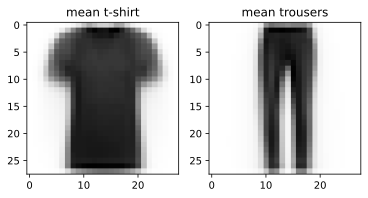

In [5]:
# Plot the two class means side by side
d2l.set_figsize((6, 3))
_, axes = d2l.plt.subplots(1, 2)
axes[0].imshow(ave_0.reshape(28, 28).tolist(), cmap='Greys')
axes[0].set_title('mean t-shirt')
axes[1].imshow(ave_1.reshape(28, 28).tolist(), cmap='Greys')
axes[1].set_title('mean trousers')
d2l.plt.show()

In a fully machine learned solution, we would learn the threshold from the
dataset. Here we set it geometrically instead: the normal is the difference of
the two class means $\mathbf{w} = \overline{\mathbf{x}}_1 - \overline{\mathbf{x}}_0$,
and the natural decision boundary is the hyperplane that *bisects* the two
means: $\mathbf{w}\cdot\mathbf{x} = b$ with
$b = \mathbf{w}\cdot\tfrac12(\overline{\mathbf{x}}_0 + \overline{\mathbf{x}}_1)$,
the midpoint of the two means' projections onto $\mathbf{w}$. We classify a test
image as class $1$ when it lands on the class-$1$ side, i.e.
$\mathbf{w}\cdot\mathbf{x} > b$. Note that deriving $b$ from the data this way is
*scale-equivariant*: it gives the same boundary whatever convention each
framework uses for pixel intensities, which a hand-picked numeric threshold
would not.

In [6]:
import numpy as onp
def as_numpy(x):
    if hasattr(x, 'asnumpy'):                   # MXNet
        return x.asnumpy()
    if hasattr(x, 'detach'):                    # PyTorch
        return x.detach().cpu().numpy()
    if hasattr(x, 'numpy'):                     # TensorFlow
        return x.numpy()
    return onp.asarray(x)                       # JAX / NumPy

X_test_np, y_test_np = as_numpy(X_test), as_numpy(y_test)
ave_0_np, ave_1_np = as_numpy(ave_0), as_numpy(ave_1)
# Normal = difference of class means; threshold = midpoint of their projections
w = (ave_1_np - ave_0_np).ravel()
b = onp.dot(w, (ave_0_np + ave_1_np).ravel()) / 2
predictions = X_test_np.reshape(len(X_test_np), -1).dot(w) > b

# Accuracy
onp.mean(predictions.astype(y_test_np.dtype) == y_test_np, dtype=onp.float64)

np.float64(0.9155)

This rule classifies about $92\%$ of the
$2{,}000$ test images correctly, and *nothing was trained*. We computed two
class means, took their difference as the normal $\mathbf{w}$, and asked of
each test image only which side of one hyperplane its $784$-dimensional pixel
vector lies on. To see the geometry of why such a crude rule works, project
every test image onto the normal: reduce each image to the single
number $\mathbf{w}\cdot\mathbf{x}$, its (scaled) signed position along the
direction from "mean t-shirt" to "mean trousers", and histogram the two
classes separately.

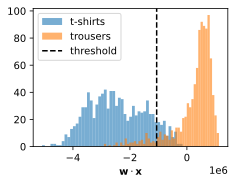

In [7]:
import numpy as onp
# Histogram of the test images' projections onto the normal direction w
proj = X_test_np.reshape(len(X_test_np), -1).dot(w)
d2l.set_figsize()
d2l.plt.hist(proj[y_test_np == 0], bins=50, alpha=0.6, label='t-shirts')
d2l.plt.hist(proj[y_test_np == 1], bins=50, alpha=0.6, label='trousers')
d2l.plt.axvline(float(b), color='black', linestyle='--', label='threshold')
d2l.plt.xlabel(r'$\mathbf{w}\cdot\mathbf{x}$')
d2l.plt.legend()
d2l.plt.show()

This plot summarizes the key points of hyperplane classifiers. Along the single direction
$\mathbf{w}$, the two classes form two well-separated humps, and the dashed
threshold (the value of $\mathbf{w}\cdot\mathbf{x}$ at the midpoint of the
two means) cuts between them; the tails that spill across it are exactly the
$\approx 8\%$ of images the rule misclassifies. A *learned* linear classifier, such as the softmax
regression of that section, improves on this only by moving and
tilting the same kind of boundary to cut the overlap more cleverly. A deep
network goes one step further: it learns a new representation under which the
two humps separate so widely that a hyperplane between them becomes trivial to
place.

## Matrices as Linear Maps

### Linear Transformations

Through that section and the above discussions,
we have a solid understanding of the geometry of vectors, lengths, and angles.
The remaining object is a geometric understanding of the linear
transformations that matrices represent, and two dimensions are the place to
build it.

Suppose that we have some matrix:

$$
\mathbf{A} = \begin{bmatrix}
a & b \\ c & d
\end{bmatrix}.
$$

If we want to apply this to an arbitrary vector
$\mathbf{v} = [x, y]^\top$,
we multiply and see that

$$
\begin{aligned}
\mathbf{A}\mathbf{v} & = \begin{bmatrix}a & b \\ c & d\end{bmatrix}\begin{bmatrix}x \\ y\end{bmatrix} 
& = \begin{bmatrix}ax+by\\ cx+dy\end{bmatrix} \\
& = x\begin{bmatrix}a \\ c\end{bmatrix} + y\begin{bmatrix}b \\d\end{bmatrix} 
& = x\left\{\mathbf{A}\begin{bmatrix}1\\0\end{bmatrix}\right\} + y\left\{\mathbf{A}\begin{bmatrix}0\\1\end{bmatrix}\right\}.
\end{aligned}
$$

This may seem like an odd computation,
where something clear became somewhat impenetrable.
However, it tells us that we can write the way
that a matrix transforms *any* vector
in terms of how it transforms *two specific vectors*:
$[1,0]^\top$ and $[0,1]^\top$.
We have reduced an infinite problem
(what happens to any pair of real numbers)
to a finite one (what happens to these specific vectors).
The vectors $[1,0]^\top$ and $[0,1]^\top$ are exactly the standard basis
$\mathbf{e}_1, \mathbf{e}_2$ from our discussion of spans and bases: because
every vector is a (unique) weighted sum of basis vectors, knowing where a
matrix sends a basis determines where it sends everything.

Let's draw what happens when we use the specific matrix

$$
\mathbf{A} = \begin{bmatrix}
1 & 2 \\
-1 & 3
\end{bmatrix}.
$$

If we look at the specific vector $\mathbf{v} = [2, -1]^\top$,
we see this is $2\cdot[1,0]^\top - [0,1]^\top$,
and thus we know that the matrix $\mathbf{A}$ will send this to
$2\,\mathbf{A}[1,0]^\top - \mathbf{A}[0,1]^\top = 2[1, -1]^\top - [2,3]^\top = [0, -5]^\top$.
If we follow this logic through carefully,
say by considering the grid of all integer pairs of points,
we see that what happens is that the matrix multiplication
can skew, rotate, and scale the grid,
but the grid structure must remain as you see in the figure.

![The matrix $\mathbf{A} = \bigl(\begin{smallmatrix}1 & 2 \\ -1 & 3\end{smallmatrix}\bigr)$ acting on the plane. The basis vectors are sent to $\mathbf{A}\mathbf{e}_1 = (1, -1)^\top$ and $\mathbf{A}\mathbf{e}_2 = (2, 3)^\top$, and the entire grid is transported along with them: lines stay lines, the origin stays put, and equally spaced cells stay equally spaced. The shaded unit square maps to the shaded parallelogram, whose area will be the subject of the determinant below.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-linear-map.svg)

The point to internalize about linear transformations represented by matrices:
matrices are incapable of distorting some parts of space differently than others.
All they can do is take the original coordinates on our space
and skew, rotate, and scale them.

Some distortions can be severe.  For instance the matrix

$$
\mathbf{B} = \begin{bmatrix}
2 & -1 \\ 4 & -2
\end{bmatrix},
$$

compresses the entire two-dimensional plane down to a single line.
Identifying and working with such transformations are the topic of a later section,
but geometrically we can see that this is fundamentally different
from the types of transformations we saw above.
For instance, the result from matrix $\mathbf{A}$ can be "bent back" to the original grid.  The results from matrix $\mathbf{B}$ cannot
because we will never know where the vector $[1,2]^\top$ came from: was
it $[1,1]^\top$ or $[0, -1]^\top$?

While this picture was for a $2\times2$ matrix,
nothing prevents us from taking the lessons learned into higher dimensions.
If we take similar basis vectors like $[1,0, \ldots,0]$
and see where our matrix sends them,
we can start to get a feeling for how the matrix multiplication
distorts the entire space in whatever dimension space we are dealing with.

Nothing requires the matrix to be square, either. An $m \times n$ matrix takes
vectors with $n$ entries to vectors with $m$ entries: it is a linear map
*between* spaces, from $\mathbb{R}^n$ to $\mathbb{R}^m$, and it is still
determined by where it sends the $n$ basis vectors (whose images are its
columns). A $2 \times 3$ matrix has an image of dimension at most two; it
fills the output plane only when its rank is two. A $3 \times 2$ matrix has a
plane through the origin as its image when its rank is two, and a line or the
origin at lower rank. Every fully connected layer of a
neural network is exactly such a map between spaces of different dimensions,
composed with a nonlinearity.

### Orthogonal Matrices

A matrix may skew, rotate, and scale, but a special and important family does
*only* the rigid part: it rotates or reflects without any stretching. A square
matrix $\mathbf{Q}$ is called **orthogonal** when its columns are orthonormal,
which we can write compactly as $\mathbf{Q}^\top\mathbf{Q} = \mathbf{I}$. The
defining property of such maps is that they **preserve lengths and angles**,
because they preserve every dot product:

$$
(\mathbf{Q}\mathbf{x})\cdot(\mathbf{Q}\mathbf{y})
 = (\mathbf{Q}\mathbf{x})^\top(\mathbf{Q}\mathbf{y})
 = \mathbf{x}^\top\mathbf{Q}^\top\mathbf{Q}\,\mathbf{y}
 = \mathbf{x}^\top\mathbf{y}
 = \mathbf{x}\cdot\mathbf{y}.
$$

Taking $\mathbf{y} = \mathbf{x}$ shows $\|\mathbf{Q}\mathbf{x}\| =
\|\mathbf{x}\|$, so an orthogonal map is a rigid motion of space. Since
$\mathbf{Q}^\top\mathbf{Q} = \mathbf{I}$ means $\mathbf{Q}^{-1} =
\mathbf{Q}^\top$, such maps are trivially invertible, and as we will prove
when we meet the determinant at the end of this section, their volume scaling
is $\det\mathbf{Q} = \pm 1$ (the sign distinguishing rotations from
reflections). Orthogonal matrices are the "distortion-free" linear maps, and
they will turn out to be the building blocks
of the two decompositions in the sections that follow: the spectral theorem
writes a symmetric matrix as $\mathbf{Q}\boldsymbol\Lambda\mathbf{Q}^\top$
(that section), and the singular value decomposition
writes *any* matrix as orthogonal–diagonal–orthogonal
(that section).

Where do orthonormal columns come from in the first place? Any linearly
independent collection can be converted into an orthonormal basis of its span
by the *Gram–Schmidt process*: walk through the vectors in order, subtract
from each one its projection the equation onto each direction
already produced, and normalize what remains. In matrix form this algorithm is
the *QR factorization*, the `qr` call that produced the orthonormal basis
in our subspace-projection demo earlier in this section. We will not need its
inner workings in this chapter; it is enough to know that orthonormal bases
are cheap to compute, which is one reason the decompositions built from
them are so practical.

### Linear Dependence, Rank, and Invertibility

Consider again the matrix

$$
\mathbf{B} = \begin{bmatrix}
2 & -1 \\ 4 & -2
\end{bmatrix}.
$$

This compresses the entire plane down to live on the single line $y = 2x$.
The question now arises: is there some way we can detect this
just looking at the matrix itself?
The answer is that indeed we can.
Let's take $\mathbf{b}_1 = [2,4]^\top$ and $\mathbf{b}_2 = [-1, -2]^\top$
be the two columns of $\mathbf{B}$.
Remember that we can write everything transformed by the matrix $\mathbf{B}$
as a linear combination of the columns of the matrix,
like $a_1\mathbf{b}_1 + a_2\mathbf{b}_2$;
in the language of spans, the outputs of $\mathbf{B}$ fill out exactly its
column space.
The fact that $\mathbf{b}_1 = -2\cdot\mathbf{b}_2$
means that we can write any linear combination of those two columns
entirely in terms of say $\mathbf{b}_2$ since

$$
a_1\mathbf{b}_1 + a_2\mathbf{b}_2 = -2a_1\mathbf{b}_2 + a_2\mathbf{b}_2 = (a_2-2a_1)\mathbf{b}_2.
$$

This means that one of the columns is, in a sense, redundant
because it does not define a unique direction in space.
This should not surprise us too much
since we already saw that this matrix
collapses the entire plane down into a single line.
Moreover, we see that the linear dependence
$\mathbf{b}_1 = -2\cdot\mathbf{b}_2$ captures this.
To make this more symmetrical between the two vectors, we will write this as

$$
\mathbf{b}_1  + 2\cdot\mathbf{b}_2 = 0.
$$

The coefficients $(1, 2)$ of this relation say
precisely that $\mathbf{B}[1, 2]^\top = 1\cdot\mathbf{b}_1 + 2\cdot\mathbf{b}_2
= \mathbf{0}$, so the dependence hands us a nonzero vector in the *null space*
of $\mathbf{B}$. the figure shows the two subspaces of
$\mathbf{B}$ at work together: the whole plane is crushed onto the column
space, while the null-space direction is exactly the set of inputs that land
on the origin. (For this particular $\mathbf{B}$ the two subspaces happen to
coincide as sets, both being the line $y = 2x$: a coincidence, equivalent
to $\mathbf{B}^2 = \mathbf{0}$, that makes the picture no less instructive,
since what the matrix *produces* and what it *destroys* are different roles
even when they occupy the same line.)

![The matrix $\mathbf{B} = \left(\begin{smallmatrix}2 & -1 \\ 4 & -2\end{smallmatrix}\right)$ collapsing the plane. Left: the input plane, with three marked points and the null-space direction $(1,2)^\top$ dashed; every input on that line is sent to the origin. Right: the image. The entire grid lands on the column space, the line $y = 2x$ spanned by the columns $\mathbf{b}_1$ and $\mathbf{b}_2$; the marked points land at their images, and the null-space line has collapsed to $\mathbf{0}$. Once distinct inputs collide like this, no inverse can tell them apart.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-null-collapse.svg)

In general, we will say that a collection of vectors
$\mathbf{v}_1, \ldots, \mathbf{v}_k$ are *linearly dependent*
if there exist coefficients $a_1, \ldots, a_k$ *not all equal to zero* so that

$$
\sum_{i=1}^k a_i\mathbf{v}_i = 0.
$$

In this case, we can solve for one of the vectors
in terms of some combination of the others,
and effectively render it redundant.
Thus, a linear dependence in the columns of a matrix
is a witness to the fact that our matrix
is compressing the space down to some lower dimension.
If there is no linear dependence we say the vectors are *linearly
independent*, the same notion we met when defining bases, now read as a
property of a matrix's columns. If the columns of a matrix are linearly
independent, no compression occurs and the operation can be undone.

#### Rank

If we have a general $m\times n$ matrix,
it is reasonable to ask the dimension of the space the matrix maps *onto*,
the dimension of its image.
A concept known as the *rank* will be our answer.
In the previous section, we noted that a linear dependence
bears witness to compression of space into a lower dimension
and so we will be able to use this to define the notion of rank.
In particular, the rank of a matrix $\mathbf{A}$
is the largest number of linearly independent columns
amongst all subsets of columns. For example, our matrix

$$
\mathbf{B} = \begin{bmatrix}
2 & -1 \\ 4 & -2
\end{bmatrix}
$$

from above has $\textrm{rank}(\mathbf{B})=1$, since the two columns
$[2, 4]^\top$ and $[-1, -2]^\top$ are linearly dependent,
while each column on its own is linearly independent.
For a more challenging example, we can consider

$$
\mathbf{C} = \begin{bmatrix}
1& 3 & 0 & -1 & 0 \\
-1 & 0 & 1 & 1 & -1 \\
0 & 3 & 1 & 0 & -1 \\
2 & 3 & -1 & -2 & 1
\end{bmatrix},
$$

and show that $\mathbf{C}$ has rank two since, for instance,
the first two columns are linearly independent,
however any of the $\binom{5}{3} = 10$ collections of three columns are
linearly dependent. (Exercise: verify this, either by hand or with
`matrix_rank`.)

Equivalently, the rank is the *dimension of the column space* we defined
alongside spans and bases, and a foundational theorem of linear algebra says
this equals the dimension of the *row space*, the span of the rows. A matrix
"compresses space" into a lower dimension exactly when its rank is smaller
than its number of columns, equivalently, when its null space contains some
nonzero vector.

This procedure, as described, is very inefficient.
It requires looking at every subset of the columns of our given matrix,
and thus is potentially exponential in the number of columns.
Later we will see a more computationally efficient way
to compute the rank of a matrix, but for now,
this is sufficient to see that the concept
is well defined and understand the meaning.

The trade-off between compression and survival is exact.

**Proposition (rank--nullity).** *For an $m \times n$ matrix $\mathbf{A}$,*

$$
\operatorname{rank}\mathbf{A} + \dim\ker\mathbf{A} = n,
$$

*where $\ker\mathbf{A}$ denotes the null space.*

**Proof.** Choose a basis $\mathbf{w}_1, \ldots, \mathbf{w}_k$ of the null
space and extend it to a basis $\mathbf{w}_1, \ldots, \mathbf{w}_k,
\mathbf{v}_1, \ldots, \mathbf{v}_{n-k}$ of $\mathbb{R}^n$. The images
$\mathbf{A}\mathbf{v}_1, \ldots, \mathbf{A}\mathbf{v}_{n-k}$ span the column
space (the $\mathbf{w}_i$ contribute nothing), and they are independent: if
$\sum_i c_i \mathbf{A}\mathbf{v}_i = \mathbf{0}$ then $\sum_i c_i \mathbf{v}_i$
lies in the null space, hence is a combination of the $\mathbf{w}_j$,
impossible within a basis unless every $c_i = 0$. So the column space has
dimension exactly $n - k$. $\blacksquare$

Read it as conservation of directions: of the $n$ directions coming in,
$\dim\ker\mathbf{A}$ are destroyed and $\operatorname{rank}\mathbf{A}$
survive. $\mathbf{B}$ has $1 + 1 = 2$, one column-space direction
surviving and one null-space
direction crushed, exactly as the figure shows. The
singular value decomposition will make this split visible, with orthonormal
bases attached to both halves, in that section.

#### Invertibility

We have seen above that multiplication by a matrix with linearly dependent columns
cannot be undone, i.e., there is no inverse operation that can always recover the input.  However, multiplication by a *full-rank* matrix
(an $n \times n$ matrix $\mathbf{A}$ with rank $n$)
can always be undone.  Consider the matrix

$$
\mathbf{I} = \begin{bmatrix}
1 & 0 & \cdots & 0 \\
0 & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1
\end{bmatrix}.
$$

which is the matrix with ones along the diagonal, and zeros elsewhere.
We call this the *identity* matrix.
It is the matrix which leaves our data unchanged when applied.
To find a matrix which undoes what our matrix $\mathbf{A}$ has done,
we want to find a matrix $\mathbf{A}^{-1}$ such that

$$
\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\mathbf{A}^{-1} =  \mathbf{I}.
$$

If we look at this as a system, we have $n \times n$ unknowns
(the entries of $\mathbf{A}^{-1}$) and $n \times n$ equations
(the equality that needs to hold between every entry of the product $\mathbf{A}^{-1}\mathbf{A}$ and every entry of $\mathbf{I}$)
so we should generically expect a solution to exist.
"Generically" is made precise by the *determinant*, introduced below: a
solution exists exactly when the determinant is nonzero.
We call such a matrix $\mathbf{A}^{-1}$ the *inverse* matrix.
As an example, if $\mathbf{A}$ is the general $2 \times 2$ matrix

$$
\mathbf{A} = \begin{bmatrix}
a & b \\
c & d
\end{bmatrix},
$$

then we can see that the inverse is

$$
 \frac{1}{ad-bc}  \begin{bmatrix}
d & -b \\
-c & a
\end{bmatrix}.
$$

We can test to see this by seeing that multiplying
by the inverse given by the formula above works in practice.

In [8]:
import numpy as onp
M = onp.array([[1, 2], [1, 4]])
M_inv = onp.array([[2, -1], [-0.5, 0.5]])
M_inv.dot(M)

array([[1., 0.],
       [0., 1.]])

#### Numerical Issues
While the matrix inverse is useful in theory, in practice we rarely want to
*compute* it. To solve the linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$,
call `linalg.solve(A, b)`, which factorizes $\mathbf{A}$ without ever forming
its inverse, rather than the tempting but inferior `inv(A) @ b`: just as
division by a small number is numerically unstable, so is inversion of a
matrix that is close to having low rank. Sparsity raises the stakes further.
A matrix with a million rows and columns but only $5$ million non-zero entries
is cheap to store, yet its inverse is typically dense, with on the order of
$10^{12}$ non-zero entries. The quantity that makes "close to low rank"
precise, and that measures exactly how much a solve can amplify error, is the
condition number of that section.

### The Determinant
The geometric view of linear algebra gives an intuitive way
to interpret a fundamental quantity known as the *determinant*.
Return to the grid picture of the figure and watch the
shaded unit square, the square with edges $\mathbf{e}_1 = (1,0)^\top$ and
$\mathbf{e}_2 = (0,1)^\top$, hence with area one. The matrix

$$
\mathbf{A} = \begin{bmatrix}
1 & 2 \\
-1 & 3
\end{bmatrix}
$$

carries it to the shaded parallelogram with edges
$\mathbf{A}\mathbf{e}_1 = [1, -1]^\top$ and $\mathbf{A}\mathbf{e}_2 = [2, 3]^\top$.
There is no reason this parallelogram should have the same area
that we started with, and indeed an exercise in coordinate geometry
shows that its area is exactly $5$: this particular matrix
quintuples areas.

In general, a matrix

$$
\mathbf{A} = \begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

sends the unit square to the parallelogram with edges $(a, c)^\top$ and
$(b, d)^\top$, and we can compute that parallelogram's area directly. Suppose
for the moment that all four entries are positive and that $(a, c)^\top$ makes
the smaller angle with the $x$-axis. The parallelogram has vertices $(0,0)$,
$(a, c)$, $(b, d)$, and $(a+b, c+d)$; enclose it in its bounding rectangle
$[0, a+b] \times [0, c+d]$. The part of the rectangle outside the
parallelogram consists of two $b \times c$ rectangles in the corners, two
right triangles with legs $a$ and $c$, and two right triangles with legs $b$
and $d$. Subtracting all six pieces from the rectangle's area leaves

$$
(a+b)(c+d) - 2bc - 2\cdot\tfrac{1}{2}\,ac - 2\cdot\tfrac{1}{2}\,bd = ad - bc.
$$

Working through the other sign configurations changes only the sign of the
result, never its magnitude: the parallelogram's area is always $|ad - bc|$.
The signed quantity $ad-bc$
is referred to as the *determinant*, written $\det\mathbf{A}$.

Let's quickly confirm the worked example in code: for the matrix
$\mathbf{A}$ above the determinant should come out to
$1 \cdot 3 - 2 \cdot (-1) = 5$.

In [9]:
import numpy as onp
onp.linalg.det(onp.array([[1, 2], [-1, 3]]))

np.float64(4.999999999999999)

Note that the expression $ad - bc$ can be zero or even negative, and
the figure shows the three possible regimes side by
side, each for a different matrix: a positive determinant, where the unit
square maps to a parallelogram of area $\det\mathbf{A}$; a negative
determinant, where the parallelogram has area $|\det\mathbf{A}|$ but the map
has *flipped the orientation* of the plane (the images of $\mathbf{e}_1$ and
$\mathbf{e}_2$ have traded sides); and a zero determinant, where the square is
crushed to a segment. The negative case is a matter of convention taken
generally in mathematics: if the matrix flips the figure, we say the area is
negated.

![The determinant as a signed area, shown for three different matrices. The unit square spanned by the basis vectors (dashed) maps to the parallelogram spanned by the columns of each matrix, and the signed area of that parallelogram is the determinant: (a) positive; (b) negative, because the matrix flips orientation; (c) zero, because the matrix collapses the square to a segment.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-la-determinant.svg)

Let's see now that when the determinant is zero, we learn more.
Consider our compressing matrix from before,

$$
\mathbf{B} = \begin{bmatrix}
2 & -1 \\ 4 & -2
\end{bmatrix}.
$$

If we compute the determinant of this matrix,
we get $2\cdot(-2) - (-1)\cdot 4 = 0$.
Given our understanding above, this makes sense.
$\mathbf{B}$ compresses the unit square
down to a segment of the line $y = 2x$, which has zero area:
the situation of panel (c) in the figure, and exactly
the collapse pictured in the figure.
And indeed, being compressed into a lower dimensional space
is the only way to have zero area after the transformation.
Thus we see the following result is true:
a matrix $A$ is invertible if and only if
the determinant is not equal to zero. We prove this equivalence below, once
the determinant exists in every dimension.

#### The Determinant in General

The two-dimensional picture says what the determinant of an $n \times n$
matrix should be: the signed volume of the parallelepiped spanned by its
columns. Rather than wrestle with $n$-dimensional geometry directly, we
distill the three properties of signed volume that determine it completely,
stated for the columns $\mathbf{a}_1, \ldots, \mathbf{a}_n$ of an
$n \times n$ matrix:

1. **Multilinear**: $\det$ is linear in each column separately, with the other
   columns held fixed. (Scaling one edge of a parallelepiped scales its
   volume; splitting one edge as a sum splits the volume accordingly.)
2. **Alternating**: $\det$ is zero whenever two columns are equal. (The
   parallelepiped then flattens into a lower-dimensional slab of zero volume.)
3. **Normalized**: $\det \mathbf{I} = 1$. (The unit cube has volume one.)

The granted fact for this subsection, which we use without proof, is that
there is exactly *one* function of the columns with these three properties;
it is the determinant (see [@Horn.Johnson.2012] for the construction and
the uniqueness argument). Uniqueness comes in a sharper form that we will use
below: *every* function $f$ of the columns satisfying (1) and (2) is a
multiple of the determinant, $f = f(\mathbf{I}) \cdot \det$. To see why, set
$g = f - f(\mathbf{I})\cdot\det$; then $g$ satisfies (1) and (2) with
$g(\mathbf{I}) = 0$, so $g + \det$ satisfies all three properties, hence
equals $\det$ by uniqueness, forcing $g = 0$.

The three properties are a machine for producing identities. First,
**swapping two columns flips the sign of the determinant**. Place the vector
$\mathbf{u}+\mathbf{v}$ in two different column slots and expand by
multilinearity:

$$
\begin{aligned}
0 &= \det(\ldots, \mathbf{u}+\mathbf{v}, \ldots, \mathbf{u}+\mathbf{v}, \ldots) \\
  &= \det(\ldots, \mathbf{u}, \ldots, \mathbf{u}, \ldots)
   + \det(\ldots, \mathbf{u}, \ldots, \mathbf{v}, \ldots)
   + \det(\ldots, \mathbf{v}, \ldots, \mathbf{u}, \ldots)
   + \det(\ldots, \mathbf{v}, \ldots, \mathbf{v}, \ldots).
\end{aligned}
$$

The left-hand side, the first term, and the last term all vanish by the
alternating property, leaving

$$
\det(\ldots, \mathbf{u}, \ldots, \mathbf{v}, \ldots)
 = -\det(\ldots, \mathbf{v}, \ldots, \mathbf{u}, \ldots).
$$

This is where the *sign* of the signed area comes from: exchanging two edges
reverses the orientation of the parallelepiped, and an odd permutation of the
columns negates the determinant.

Second, the three properties pin down a formula. Expand each column in the
standard basis, $\mathbf{a}_j = \sum_i a_{ij}\,\mathbf{e}_i$, and apply
multilinearity column by column: $\det\mathbf{A}$ becomes a sum of terms of
the form $a_{i_1 1} a_{i_2 2} \cdots a_{i_n n}
\det(\mathbf{e}_{i_1}, \ldots, \mathbf{e}_{i_n})$. Whenever two of the chosen
row indices coincide, the term dies by the alternating property; when all are
distinct, the columns $\mathbf{e}_{i_1}, \ldots, \mathbf{e}_{i_n}$ are a
reshuffling of the identity matrix's, so repeated column swaps reduce the
determinant factor to $\pm 1$. For a $2 \times 2$ matrix with columns
$\mathbf{a}_1 = a\,\mathbf{e}_1 + c\,\mathbf{e}_2$ and
$\mathbf{a}_2 = b\,\mathbf{e}_1 + d\,\mathbf{e}_2$, the expansion has four
terms; the two with a repeated basis vector vanish and

$$
\det(\mathbf{a}_1, \mathbf{a}_2)
 = ad\,\det(\mathbf{e}_1, \mathbf{e}_2)
 + cb\,\det(\mathbf{e}_2, \mathbf{e}_1)
 = ad - bc,
$$

recovering the parallelogram area we computed by hand. In general the
determinant is a signed sum, over all ways of picking one entry from each row
and each column, of the products of the chosen entries; this is the
permutation formula, and (1)+(2)+(3) leave no other possibility.

For hand computation the sum is organized as *cofactor expansion*: expanding
the first column in the standard basis splits $\det\mathbf{A}$ into $n$
smaller determinants, with alternating signs, of the submatrices obtained by
deleting the first column and one row. Let us work a $3 \times 3$ example,

$$
\mathbf{A} = \begin{bmatrix}
2 & 1 & 0 \\
1 & 3 & 1 \\
0 & 1 & 2
\end{bmatrix},
$$

expanding along the first column:

$$
\det \mathbf{A}
 = 2 \det \begin{bmatrix} 3 & 1 \\ 1 & 2 \end{bmatrix}
 - 1 \det \begin{bmatrix} 1 & 0 \\ 1 & 2 \end{bmatrix}
 + 0 \det \begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix}
 = 2 \cdot 5 - 1 \cdot 2 + 0 = 8.
$$

Geometrically, $\mathbf{A}$ maps the unit cube to a parallelepiped of volume
$8$, and it scales the volume of every solid by that same factor. Let us
check the equation in code, along with two consequences of the
properties above: swapping two columns flips the sign, and the determinant of
a triangular matrix is the product of its diagonal entries.

In [10]:
import numpy as onp
A = onp.array([[2, 1, 0], [1, 3, 1], [0, 1, 2]])
A_swap = onp.array([[1, 2, 0], [3, 1, 1], [1, 0, 2]])  # first two columns swapped
T = onp.array([[2, 5, 1], [0, 3, 4], [0, 0, 1]])       # upper triangular
(onp.linalg.det(A),       # 8, matching the cofactor expansion
 onp.linalg.det(A_swap),  # -8: a column swap flips the sign
 onp.linalg.det(T))       # 6 = 2 * 3 * 1, the diagonal product

(np.float64(8.000000000000002),
 np.float64(-8.000000000000002),
 np.float64(6.0))

The triangular rule deserves its one-paragraph proof, since the next section
relies on it. Suppose $\mathbf{T}$ is upper triangular, so $t_{ij} = 0$
whenever $i > j$. Each term of the permutation formula picks one entry from
every column, all in distinct rows. To be nonzero, the entry picked from
column $1$ must come from row $1$ (every lower entry vanishes); the entry from
column $2$ must then come from row $2$ (row $1$ is taken and rows $3, \ldots,
n$ hold zeros); continuing across the columns, only the diagonal choice
survives. That single term carries the sign of no swaps at all, so

$$
\det \mathbf{T} = t_{11} t_{22} \cdots t_{nn},
$$

the product of the diagonal entries. The same argument, run from column $n$
backwards, handles lower triangular matrices.

One more identity rounds out the toolkit: $\det \mathbf{A}^\top =
\det \mathbf{A}$. For $2 \times 2$ matrices this is visible at a glance, since
transposing swaps $b$ and $c$ and leaves $ad - bc$ unchanged. In general,
transposing merely reindexes the permutation formula: each product of $n$
entries, one from every row and every column, appears in both expansions with
the same sign (see [@Horn.Johnson.2012] for the bookkeeping). One
consequence: everything the determinant says about columns holds verbatim for
rows.

#### The Unifying Theorem

The equivalence between a zero determinant, linearly dependent columns, and
failure of invertibility connects three notions we have met separately. We
state it once, with a proof we can carry out by hand in two dimensions.

**Proposition (the unifying theorem).** *For a square matrix $\mathbf{A}$, the
following are equivalent:*
(i) *$\det\mathbf{A} = 0$;*
(ii) *the columns of $\mathbf{A}$ are linearly dependent;*
(iii) *$\mathbf{A}$ is not invertible.*

**Proof (for the $2 \times 2$ case).** We give the argument for the
$2 \times 2$ matrix
$\mathbf{A} = \bigl[\begin{smallmatrix} a & b \\ c & d \end{smallmatrix}\bigr]$,
where every step is a picture. Write the two
columns as $\mathbf{a}_1 = [a, c]^\top$ and $\mathbf{a}_2 = [b, d]^\top$. As we
saw above, $\det\mathbf{A} = ad - bc$ is the *signed area* of the parallelogram
spanned by $\mathbf{a}_1$ and $\mathbf{a}_2$.

*(i) $\Leftrightarrow$ (ii).* A parallelogram has zero area exactly when its two
spanning edges are collinear, i.e., when one column is a scalar multiple of the
other (including the degenerate case where a column is $\mathbf{0}$). That is
precisely linear dependence of the columns. So $ad - bc = 0$ if and only if
$\mathbf{a}_1$ and $\mathbf{a}_2$ are linearly dependent.

*(ii) $\Leftrightarrow$ (iii).* If the columns are dependent, every output
$\mathbf{A}\mathbf{x} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2$ lies on the single
line spanned by the surviving column, so the whole plane is crushed onto that
line. Distinct inputs collide there (the map is not one-to-one), so no inverse
can recover them, and $\mathbf{A}$ is not invertible. Conversely, if the columns
are independent they span the plane, every target is hit exactly once, and the
map can be undone; concretely, $ad - bc \neq 0$ is exactly the nonvanishing
denominator that made the explicit inverse
$\frac{1}{ad-bc}\bigl[\begin{smallmatrix} d & -b \\ -c & a \end{smallmatrix}\bigr]$
well-defined earlier in this section. $\blacksquare$

In $n$ dimensions the same equivalences hold, and the axiomatic
characterization of that section supplies the two
ingredients that generalize: $\det\mathbf{A}$ is the signed factor by which
$\mathbf{A}$ scales $n$-dimensional volume, and that volume vanishes exactly
when the columns are linearly dependent; see [@Horn.Johnson.2012] for the
full argument. The equivalence also proves claims made earlier without proof:
linear dependence (the columns of $\mathbf{B}$ are redundant), the missing
$ad - bc \neq 0$ hypothesis under the $2 \times 2$ inverse, and the present
section's "$\det = 0$ means collapse" all turn out to be three faces of the
same fact.

#### Multiplicativity

Imagine that we have any figure drawn on the plane.
Thinking like computer scientists, we can decompose
that figure into a collection of little squares
so that the area of the figure is in essence
just the number of squares in the decomposition.
If we now transform that figure by a matrix,
we send each of these squares to parallelograms,
each one of which has area given by the determinant.
We see that for any figure, the determinant gives the (signed) number
that a matrix scales the area of any figure.

This "scale every figure's area by the same factor" reading has an immediate
consequence for *composing* two transformations. First, a fact that deserves
its own sentence: **matrix multiplication is composition of linear
maps**. Applying $\mathbf{B}$ and then $\mathbf{A}$ to an input $\mathbf{v}$
produces $\mathbf{A}(\mathbf{B}\mathbf{v})$, and writing out components,

$$
\bigl(\mathbf{A}(\mathbf{B}\mathbf{v})\bigr)_i
 = \sum_j a_{ij} (\mathbf{B}\mathbf{v})_j
 = \sum_j \sum_k a_{ij} b_{jk} v_k
 = \bigl((\mathbf{A}\mathbf{B})\mathbf{v}\bigr)_i,
$$

so running the two maps in turn is the same as applying the single matrix
$\mathbf{A}\mathbf{B}$. This is the real reason matrix multiplication is
defined by the row-times-column rule, and it explains why the product is
associative but not commutative: composing functions in the other order
generally gives a different function. With composition in hand, we can prove
that the determinant is multiplicative.

**Proposition (multiplicativity of the determinant).** *For square matrices
$\mathbf{A}$ and $\mathbf{B}$ of the same size,*

$$
\det(\mathbf{A}\mathbf{B}) = \det(\mathbf{A})\,\det(\mathbf{B}).
$$

**Geometric intuition.** Apply $\mathbf{A}\mathbf{B}$ to an arbitrary figure
of area $V$ by running the two maps in turn. First $\mathbf{B}$ acts and
scales the area to $\det(\mathbf{B})\,V$; then $\mathbf{A}$ acts and scales
that by a further factor of $\det(\mathbf{A})$. But the composite map
$\mathbf{A}\mathbf{B}$ is itself a single linear transformation, which scales
area by its own determinant, so the two factors must multiply to
$\det(\mathbf{A}\mathbf{B})$. This argument leans on the tiling picture above
(a linear map scales *every* figure's volume by one common factor), which we
made plausible but did not prove; the axioms of
that section turn it into a proof.

**Proof.** Fix $\mathbf{A}$ and consider, as a function of $\mathbf{B}$, the
quantity $D(\mathbf{B}) = \det(\mathbf{A}\mathbf{B})$. The $j$-th column of
$\mathbf{A}\mathbf{B}$ is $\mathbf{A}\mathbf{b}_j$, where $\mathbf{b}_j$ is
the $j$-th column of $\mathbf{B}$. Because $\mathbf{A}(\cdot)$ is linear and
$\det$ is multilinear, $D$ is multilinear in the columns of $\mathbf{B}$; and
if two columns of $\mathbf{B}$ are equal, then so are the corresponding
columns of $\mathbf{A}\mathbf{B}$, making $D(\mathbf{B}) = 0$, so $D$ is
alternating. By the scaling form of uniqueness from
that section,

$$
\det(\mathbf{A}\mathbf{B}) = D(\mathbf{B}) = D(\mathbf{I})\,\det(\mathbf{B})
 = \det(\mathbf{A})\,\det(\mathbf{B}). \qquad \blacksquare
$$

A corollary is one line long but easy to miss.

**Corollary.** *For square matrices $\mathbf{A}$ and $\mathbf{B}$ of the same
size,*

$$
\det(\mathbf{A}\mathbf{B}) = \det(\mathbf{A})\,\det(\mathbf{B})
 = \det(\mathbf{B})\,\det(\mathbf{A}) = \det(\mathbf{B}\mathbf{A}).
$$

Even though $\mathbf{A}\mathbf{B} \neq \mathbf{B}\mathbf{A}$ in general, their
determinants always agree, because the two determinants are scalars and
scalars commute. This is a genuinely useful fact: applied to the pair
$\mathbf{W}\mathbf{A}$ and $\mathbf{W}^{-1}$, it gives *similarity
invariance*, $\det(\mathbf{W}\mathbf{A}\mathbf{W}^{-1}) =
\det(\mathbf{W}^{-1}\mathbf{W}\mathbf{A}) = \det(\mathbf{A})$: matrices that
represent the same linear map in different bases have the same determinant,
a fact that section puts to work.

Further consequences follow without any additional work. First, taking
$\mathbf{B} = \mathbf{A}^{-1}$ in the equation and using
$\det(\mathbf{I}) = 1$ (the identity moves no volume) gives

$$
\det(\mathbf{A}^{-1}) = \frac{1}{\det(\mathbf{A})},
$$

which also re-confirms the unifying theorem: an inverse can exist only when
$\det(\mathbf{A}) \neq 0$, since otherwise the right-hand side is undefined.
Second, we can prove the claim made in the orthogonal-matrices
subsection. Combining multiplicativity with $\det\mathbf{Q}^\top =
\det\mathbf{Q}$ from that section and applying
both to $\mathbf{Q}^\top\mathbf{Q} = \mathbf{I}$ gives

$$
\det(\mathbf{Q})^2 = \det(\mathbf{Q}^\top)\det(\mathbf{Q})
 = \det(\mathbf{Q}^\top\mathbf{Q}) = \det(\mathbf{I}) = 1,
$$

so $\det\mathbf{Q} = \pm 1$: a rigid motion leaves every area and volume
unchanged in magnitude, and the sign records whether it is a pure rotation
($+1$) or involves a reflection ($-1$).
Third, and looking ahead, similarity invariance is exactly what lets the
determinant pass through a diagonalization: once we can write a matrix in
terms of its eigenvalues in that section, the same
identities will show that the determinant is the *product of the
eigenvalues*, $\det(\mathbf{A}) = \prod_i \lambda_i$, the volume scaling
being the product of the per-axis stretch factors.

## Tensors and Einstein Summation

We close with a compact notation for all of these products at once. Every
product in this section (dot products, matrix–vector products,
matrix products, and the *trace* $\textrm{tr}(\mathbf{A}) = \sum_i a_{ii}$,
the sum of the diagonal entries) follows one pattern: multiply entries, then
sum over the index that appears twice,

$$
\mathbf{v} \cdot \mathbf{w} = \sum_i v_i w_i,
\qquad
(\mathbf{A}\mathbf{v})_i = \sum_j a_{ij} v_j,
\qquad
(\mathbf{A}\mathbf{B})_{ik} = \sum_j a_{ij} b_{jk},
\qquad
\textrm{tr}(\mathbf{A}) = \sum_i a_{ii}.
$$

*Einstein notation* makes the pattern the entire definition: write the indexed
factors, drop the summation sign, and sum over every index that appears more
than once. Thus $\mathbf{v}\cdot\mathbf{w} = v_i w_i$ and
$(\mathbf{A}\mathbf{B})_{ik} = a_{ij}b_{jk}$. The same rule extends unchanged
to tensors with any number of axes, where a general *tensor contraction* such
as $y_{il} = x_{ijkl}\,a_{jk}$ (summing over $j$ and $k$) has no tidy matrix
notation at all. The rule is exposed directly as
`einsum`: spell out the index pattern as a string, and the library performs
the contraction.

In [11]:
import numpy as onp
A = onp.array([[1.0, 2.0], [-1.0, 3.0]])
v = onp.array([2.0, -1.0])
(onp.einsum('i,i->', v, v),      # dot product: v.v
 onp.einsum('ij,j->i', A, v),    # matrix-vector product: Av
 onp.einsum('ij,jk->ik', A, A),  # matrix product: AA
 onp.einsum('ii->', A))          # trace: tr(A)

(np.float64(5.0),
 array([ 0., -5.]),
 array([[-1.,  8.],
        [-4.,  7.]]),
 np.float64(4.0))

The matrix here is $\mathbf{A}$ from
the figure and the vector is $\mathbf{v} = [2, -1]^\top$,
so the second entry of the output reproduces the worked example
$\mathbf{A}\mathbf{v} = [0, -5]^\top$. Index strings like
`'ij,jk->ik'` recur throughout deep learning: batched matrix products
(`'bij,bjk->bik'`), attention scores, and many custom layers are one `einsum`
call away, and we will reach for the notation whenever a computation is easier
to state in indices than in matrices, as soon as
that section, where a one-line `einsum` will rebuild a matrix
from its singular value decomposition.

Index notation also yields one-line proofs. In indices, the trace of a
product is

$$
\textrm{tr}(\mathbf{A}\mathbf{B}) = a_{ij} b_{ji} = b_{ji} a_{ij}
 = \textrm{tr}(\mathbf{B}\mathbf{A}),
$$

and the middle step costs nothing: matrix entries are numbers, so they
commute, and only the bookkeeping of the indices matters. Note that
the equation holds even when $\mathbf{A}\mathbf{B} \neq
\mathbf{B}\mathbf{A}$, just as with determinants. A corollary is that the
trace is invariant under a change of basis,

$$
\textrm{tr}(\mathbf{W}\mathbf{A}\mathbf{W}^{-1})
 = \textrm{tr}(\mathbf{A}\mathbf{W}^{-1}\mathbf{W})
 = \textrm{tr}(\mathbf{A}),
$$

the identity behind the trace–eigenvalue formula
$\textrm{tr}(\mathbf{A}) = \sum_i \lambda_i$ in
that section.

## Summary
* Vectors can be interpreted geometrically as either points or directions in space.
* Dot products define the notion of angle to arbitrarily high-dimensional spaces.
* Spans, subspaces, and bases organize collections of vectors: a basis assigns every vector of a subspace unique coordinates, and the dimension counts the basis vectors. The column space and null space of a matrix record what it can produce and what it destroys.
* Projection produces the closest point of a line (or, via the projection matrix $\mathbf{P} = \mathbf{Q}\mathbf{Q}^\top$, of any subspace) and is characterized by an orthogonal residual. This is the geometry of the least-squares problem the equation.
* Hyperplanes are high-dimensional generalizations of lines and planes.  They can be used to define decision planes that are often used as the last step in a classification task.
* Matrix multiplication can be geometrically interpreted as uniform distortions of the underlying coordinates: a matrix skews, rotates, and scales, and it treats every part of space the same way. Multiplying two matrices composes the corresponding maps.
* Orthogonal matrices are the rigid motions: they preserve lengths, angles, and (up to a sign recording reflections) volumes.
* Linear dependence is a way to tell when a collection of vectors are in a lower dimensional space than we would expect (say you have $3$ vectors living in a $2$-dimensional space). The rank of a matrix is the size of the largest subset of its columns that are linearly independent, and rank--nullity is exact: rank plus the dimension of the null space equals the number of columns.
* When a matrix's inverse is defined, matrix inversion allows us to find another matrix that undoes the action of the first. Matrix inversion is useful in theory, but requires care in practice owing to numerical instability.
* The determinant is the signed volume scaling of a matrix. It is characterized by three properties (multilinear, alternating, $\det\mathbf{I} = 1$), it flips sign under a column swap, and it satisfies $\det(\mathbf{A}\mathbf{B}) = \det(\mathbf{A})\det(\mathbf{B}) = \det(\mathbf{B}\mathbf{A})$. A nonzero determinant is equivalent to invertibility; a zero determinant means the matrix is singular.
* Tensor contractions and Einstein summation express many of the computations of machine learning in one index pattern, and in index form identities such as $\textrm{tr}(\mathbf{A}\mathbf{B}) = \textrm{tr}(\mathbf{B}\mathbf{A})$ become one-line computations.

## Exercises
1. What is the angle between
$$
\vec v_1 = \begin{bmatrix}
1 \\ 0 \\ -1 \\ 2
\end{bmatrix}, \qquad \vec v_2 = \begin{bmatrix}
3 \\ 1 \\ 0 \\ 1
\end{bmatrix}?
$$
2. True or false: $\begin{bmatrix}1 & 2\\0&1\end{bmatrix}$ and $\begin{bmatrix}1 & -2\\0&1\end{bmatrix}$ are inverses of one another?
3. Suppose that we draw a shape in the plane with area $100\textrm{m}^2$.  What is the area after transforming the figure by the matrix
$$
\begin{bmatrix}
2 & 3\\
1 & 2
\end{bmatrix}.
$$
4. Which of the following sets of vectors are linearly independent?
 * $\left\{\begin{pmatrix}1\\0\\-1\end{pmatrix}, \begin{pmatrix}2\\1\\-1\end{pmatrix}, \begin{pmatrix}3\\1\\1\end{pmatrix}\right\}$
 * $\left\{\begin{pmatrix}3\\1\\1\end{pmatrix}, \begin{pmatrix}1\\1\\1\end{pmatrix}, \begin{pmatrix}0\\0\\0\end{pmatrix}\right\}$
 * $\left\{\begin{pmatrix}1\\1\\0\end{pmatrix}, \begin{pmatrix}0\\1\\-1\end{pmatrix}, \begin{pmatrix}1\\0\\1\end{pmatrix}\right\}$
5. Suppose that you have a matrix written as $A = \begin{bmatrix}c\\d\end{bmatrix}\cdot\begin{bmatrix}a & b\end{bmatrix}$ for some choice of values $a, b, c$, and $d$.  True or false: the determinant of such a matrix is always $0$?
6. The vectors $e_1 = \begin{bmatrix}1\\0\end{bmatrix}$ and $e_2 = \begin{bmatrix}0\\1\end{bmatrix}$ are orthogonal.  What is the condition on a matrix $A$ so that $Ae_1$ and $Ae_2$ are orthogonal?
7. How can you write $\textrm{tr}(\mathbf{A}^4)$ in Einstein notation for an arbitrary matrix $A$?
8. Consider the hyperplane $\mathbf{w}\cdot\mathbf{x} = b$ with $\mathbf{w} = [3,4]^\top$ and $b = 10$.  What is the signed distance from the point $\mathbf{x} = [1,1]^\top$ to this hyperplane, and on which side of it does $\mathbf{x}$ lie?
9. The proof of Cauchy–Schwarz shows that equality holds exactly when one vector is a scalar multiple of the other. Use this to characterize when the triangle inequality $\|\mathbf{v} + \mathbf{w}\| \le \|\mathbf{v}\| + \|\mathbf{w}\|$ holds with equality, and check your characterization on $\mathbf{v} = [1,2]^\top$ paired first with $\mathbf{w} = [2,4]^\top$ and then with $\mathbf{w} = [-1,-2]^\top$.
10. Compute the projection $\operatorname{proj}_{\mathbf{w}}\mathbf{v}$ of $\mathbf{v} = [1,2,3]^\top$ onto $\mathbf{w} = [1,1,1]^\top$. Verify that the residual is orthogonal to $\mathbf{w}$ and confirm the Pythagorean identity the equation numerically.
11. In code: sample $1{,}000$ pairs of random unit vectors in $d = 10{,}000$ dimensions (draw Gaussian vectors and normalize them) and compute the cosine of the angle for each pair. Compare the empirical standard deviation to the predicted $1/\sqrt{d} = 0.01$, and report the largest $|\cos\theta|$ you observe.
12. Show that an orthogonal matrix $\mathbf{Q}$ preserves angles: for nonzero $\mathbf{x}$ and $\mathbf{y}$, the angle between $\mathbf{Q}\mathbf{x}$ and $\mathbf{Q}\mathbf{y}$ equals the angle between $\mathbf{x}$ and $\mathbf{y}$. Conclude that rotating every embedding vector in a dataset by the same orthogonal matrix leaves all cosine similarities unchanged.
13. Verify that the $4 \times 5$ matrix $\mathbf{C}$ from the rank subsection has rank two: check that the first two columns are linearly independent, and confirm, by hand or with `matrix_rank`, that every collection of three of its columns is linearly dependent.
14. Use multilinearity to prove that $\det(c\mathbf{A}) = c^n \det(\mathbf{A})$ for an $n \times n$ matrix $\mathbf{A}$ and a scalar $c$. Check the identity in code for the $3 \times 3$ matrix of the equation with $c = 2$.

[Discussions](https://d2l.discourse.group/t/1084)